# Phase 4 — Feature Engineering & Feature Importance
### Energy Demand Forecasting Project

This notebook loads the engineered hourly feature set built by
`src/features/build_features.py` and runs a quick LightGBM fit purely to
rank feature usefulness — this is exploratory, not the real modeling work
(that's Phase 7). The goal is to sanity-check the feature pipeline before
building it into every model downstream.

**Run `uv run python -m src.features.build_features` before this notebook**
if you haven't already, so the `hourly_features` DuckDB table exists.


In [10]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")


## Load engineered features

In [11]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
df = con.execute("SELECT * FROM hourly_features ORDER BY datetime").df()
con.close()

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

print(f"Shape: {df.shape}")
df.head()


Shape: (34589, 36)


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,hour,dayofweek,month,...,global_active_power_roll_max_24h,global_active_power_roll_mean_168h,global_active_power_roll_std_168h,global_active_power_roll_min_168h,global_active_power_roll_max_168h,global_active_power_diff_1h,global_active_power_diff_24h,global_active_power_pct_change_1h,global_active_power_pct_change_24h,is_flagged_anomaly
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,19.0,607.0,17,5,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,403.0,1012.0,18,5,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,86.0,1001.0,19,5,12,...,NaN,NaN,NaN,NaN,NaN,-0.590689,NaN,-0.139878,NaN,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.0,1007.0,20,5,12,...,NaN,NaN,NaN,NaN,NaN,-0.231967,NaN,-0.063864,NaN,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,25.0,1033.0,21,5,12,...,NaN,NaN,NaN,NaN,NaN,-0.131667,NaN,-0.038723,NaN,1


## Missingness check

Expect NaNs in two places: the first 168 hours (warm-up period before the
longest rolling window has enough history) and rows touching the known
Phase 1 data gaps. Both are expected — we drop them before modeling, not
because anything is wrong with the pipeline.


In [12]:
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct[missing_pct > 0]


global_active_power_roll_max_168h     5.02
global_active_power_roll_mean_168h    5.02
global_active_power_roll_std_168h     5.02
global_active_power_roll_min_168h     5.02
global_active_power_roll_mean_24h     1.69
global_active_power_roll_std_24h      1.69
global_active_power_roll_min_24h      1.69
global_active_power_roll_max_24h      1.69
global_active_power_pct_change_24h    1.67
global_active_power_diff_24h          1.67
global_active_power_lag_168h          1.64
global_active_power_lag_24h           1.22
global_active_power_diff_1h           1.18
global_active_power_pct_change_1h     1.18
global_active_power_lag_6h            1.17
global_active_power_lag_1h            1.16
sub_metering_3                        1.15
sub_metering_2                        1.15
sub_metering_1                        1.15
global_intensity                      1.15
voltage                               1.15
global_reactive_power                 1.15
global_active_power                   1.15
dtype: floa

## Prepare the modeling frame

Drop rows with any missing feature/target value, then split target vs. input features.

In [13]:
TARGET_COL = "global_active_power"

# Exclude the raw target and the (already-encoded) raw calendar columns that
# have cyclical sin/cos equivalents -- keep either the raw or the cyclical
# version to avoid redundant near-duplicate features, here we keep cyclical.
exclude_cols = [
    TARGET_COL, "hour", "dayofweek", "month", "season",
    "global_reactive_power", "voltage", "global_intensity",
    "sub_metering_1", "sub_metering_2", "sub_metering_3",
]

model_df = df.dropna()
feature_cols = [c for c in model_df.columns if c not in exclude_cols]

X = model_df[feature_cols]
y = model_df[TARGET_COL]

print(f"Rows after dropping NaN: {len(model_df):,} (dropped {len(df) - len(model_df):,})")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")


Rows after dropping NaN: 32,846 (dropped 1,743)
Feature columns (25): ['quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'global_active_power_lag_1h', 'global_active_power_lag_6h', 'global_active_power_lag_24h', 'global_active_power_lag_168h', 'global_active_power_roll_mean_24h', 'global_active_power_roll_std_24h', 'global_active_power_roll_min_24h', 'global_active_power_roll_max_24h', 'global_active_power_roll_mean_168h', 'global_active_power_roll_std_168h', 'global_active_power_roll_min_168h', 'global_active_power_roll_max_168h', 'global_active_power_diff_1h', 'global_active_power_diff_24h', 'global_active_power_pct_change_1h', 'global_active_power_pct_change_24h', 'is_flagged_anomaly']


## Time-based train/test split

A simple holdout for this exploratory fit — the last 10% of the timeline.
Proper rolling-origin backtesting comes in Phase 9; this is just to get a
reasonable feature-importance ranking without training on the full history
and testing on the same data.


In [14]:
split_idx = int(len(model_df) * 0.9)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test:  {len(X_test):,} rows ({X_test.index.min()} to {X_test.index.max()})")


Train: 29,561 rows (2006-12-23 17:00:00 to 2010-06-20 16:00:00)
Test:  3,285 rows (2010-06-20 17:00:00 to 2010-11-26 21:00:00)


## Fit LightGBM and extract feature importance

In [15]:
categorical_cols = ["quarter", "is_weekend", "is_flagged_anomaly"]
for c in categorical_cols:
    X_train[c] = X_train[c].astype("category")
    X_test[c] = X_test[c].astype("category")

model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train, categorical_feature=categorical_cols)

importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.head(20)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4152
[LightGBM] [Info] Number of data points in the train set: 29561, number of used features: 25
[LightGBM] [Info] Start training from score 1.109263


global_active_power_lag_1h            790
global_active_power_lag_168h          699
hour_cos                              613
global_active_power_lag_24h           603
hour_sin                              555
global_active_power_diff_1h           502
global_active_power_pct_change_1h     476
global_active_power_lag_6h            475
global_active_power_roll_mean_24h     405
global_active_power_diff_24h          394
global_active_power_roll_mean_168h    377
global_active_power_roll_std_24h      364
global_active_power_roll_std_168h     354
global_active_power_pct_change_24h    338
global_active_power_roll_min_24h      336
global_active_power_roll_max_24h      334
global_active_power_roll_min_168h     313
global_active_power_roll_max_168h     281
month_cos                             164
is_weekend                            151
dtype: int32

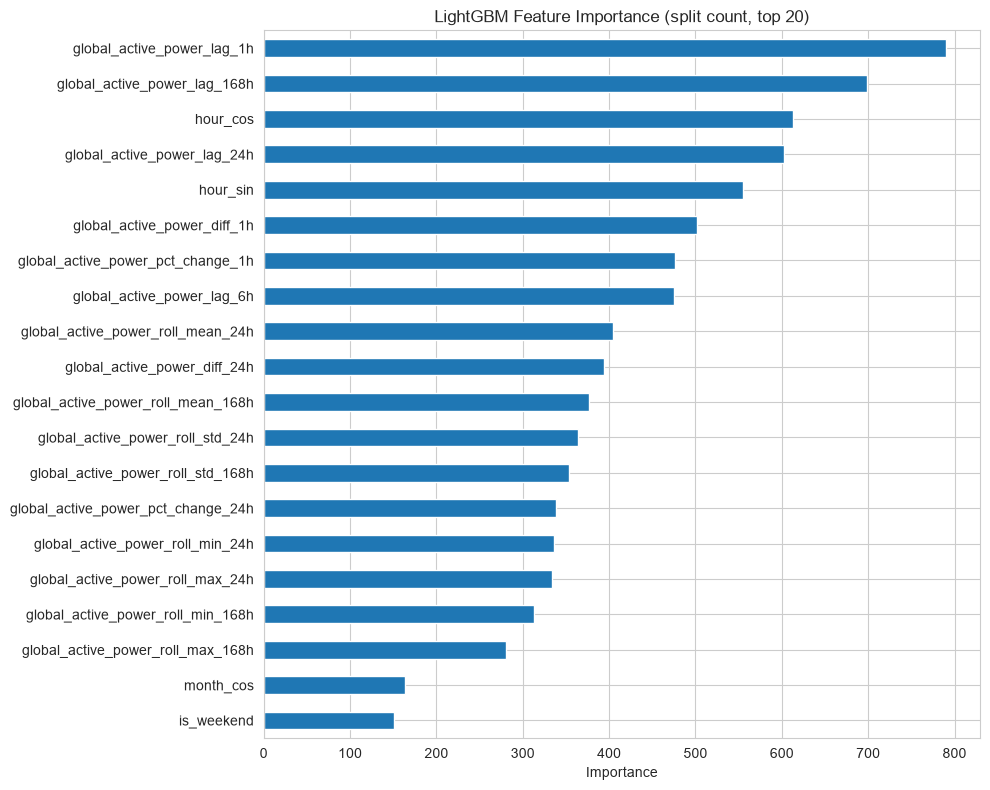

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("LightGBM Feature Importance (split count, top 20)")  # corrected label -- this is split count, not gain
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## Cross-check with mutual information

LightGBM importance reflects what THIS model happened to use — mutual
information is model-agnostic and measures general statistical dependency
between each feature and the target. Comparing the two rankings helps spot
whether LightGBM is leaning on a feature mostly because of how trees happen
to split, versus a feature that's genuinely informative by any measure.


In [17]:
# mutual_info_regression can't handle the 'category' dtype directly -- use
# the underlying numeric codes for the categorical columns just for this check.
X_mi = X_train.copy()
for c in categorical_cols:
    X_mi[c] = X_mi[c].cat.codes

mi_scores = mutual_info_regression(X_mi, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
mi_series.head(20)


global_active_power_lag_1h            0.562814
global_active_power_roll_max_168h     0.292957
global_active_power_roll_min_168h     0.290439
global_active_power_roll_min_24h      0.270932
global_active_power_lag_24h           0.229131
global_active_power_roll_max_24h      0.220521
global_active_power_lag_168h          0.206883
global_active_power_roll_mean_168h    0.194796
global_active_power_roll_std_168h     0.185373
global_active_power_roll_mean_24h     0.179964
global_active_power_diff_1h           0.176828
global_active_power_diff_24h          0.170049
global_active_power_roll_std_24h      0.145013
global_active_power_pct_change_1h     0.111530
global_active_power_lag_6h            0.099688
quarter                               0.096730
global_active_power_pct_change_24h    0.088212
month_cos                             0.077085
hour_cos                              0.074183
month_sin                             0.063192
dtype: float64

In [18]:
comparison = pd.DataFrame({
    "lgbm_importance_rank": importance.rank(ascending=False),
    "mutual_info_rank": mi_series.rank(ascending=False),
}).sort_values("lgbm_importance_rank")
comparison.head(20)


,lgbm_importance_rank,mutual_info_rank
global_active_power_lag_1h,1.0,1.0
global_active_power_lag_168h,2.0,7.0
hour_cos,3.0,19.0
global_active_power_lag_24h,4.0,5.0
hour_sin,5.0,21.0
global_active_power_diff_1h,6.0,11.0
global_active_power_pct_change_1h,7.0,14.0
global_active_power_lag_6h,8.0,15.0
global_active_power_roll_mean_24h,9.0,10.0
global_active_power_diff_24h,10.0,12.0


## Feature Engineering Findings

- **`global_active_power_lag_1h` dominates everything** — it's #1 in both LightGBM split count (790, well ahead of #2 at 699) and mutual information (0.563, nearly double the runner-up at 0.293). This is the classic short-horizon persistence effect: "an hour ago" is by far the single best predictor of "now." Practical implication for Phase 7: a trivial one-lag model is a much stronger baseline than a naive forecast, so the real modeling question becomes how much the other 24 features add *beyond* that one feature — not whether the model works at all.

- **Note on the LightGBM plot label:** the default `feature_importances_` is a split-count metric (how often a feature was used to split, across all trees), not gain-based — corrected the plot title above. If you want the loss-improvement-weighted version, refit with `LGBMRegressor(importance_type="gain")`.

- **Interesting divergence #1 — cyclical hour encoding:** `hour_cos`/`hour_sin` rank very high in LightGBM (3rd and 5th by split count) but low in mutual information (19th and 21st) individually. This isn't a contradiction — a tree ensemble can combine sin and cos jointly across multiple splits to reconstruct the real hour-of-day shape, while univariate mutual information only sees each one in isolation, where a single cosine value maps to two different hours (symmetric around noon/midnight), diluting its apparent standalone relationship with the target. **Lesson: cyclical encodings should be evaluated as a pair, not individually, when using univariate importance measures** — a good, specific thing to say in an interview about why "feature importance" isn't a single well-defined concept.

- **Interesting divergence #2 — the reverse case:** the 24h/168h rolling min/max features rank much higher in mutual information (2nd-6th) than in LightGBM split count (15th-18th). This suggests they carry real standalone statistical dependency with the target, but the tree ensemble doesn't lean on them heavily once it has already split on `lag_1h` and `roll_mean` — i.e., they're informative but largely *redundant* given what the model already has. **This is the cleanest way to describe the actual difference between the two metrics: mutual information measures raw pairwise dependency; tree split count measures marginal incremental usefulness given everything else already available.**

- **Calendar/weekly features rank low in both measures** (`is_weekend` was LightGBM's 20th at only 151 splits; `dayofweek_sin/cos` don't appear in either top-20). Best explanation: `lag_168h` (the exact same hour, one week earlier) already implicitly encodes weekly seasonality more precisely than a coarse day-type flag, so these become mostly redundant once `lag_168h` is present — another example of the same redundancy pattern as divergence #2.

- **`is_flagged_anomaly` (the Phase 3 carry-over feature) didn't surface in either top-20 list.** For one-step-ahead prediction this makes sense: `lag_1h` already reflects whatever unusual condition existed an hour ago, so the flag adds little on top. Its value is more likely to show up at longer forecast horizons (Phase 8, where the model can't lean on such a recent lag) or as an interpretability aid rather than a raw predictive signal here — worth re-testing at longer horizons rather than concluding it's useless.

- **Data-loss trade-off worth deciding on for Phase 5+:** dropping all-NaN rows removed 1,743 of 34,589 hours (5.04%), driven almost entirely by the 168h rolling window's strict requirement that *every* hour in the window be non-null — a single missing hour "poisons" up to 168 downstream rows. The 24h window loses far less (1.69%) for the same reason at smaller scale. Options going forward: keep the strict full-window requirement (simplest, what we did here), or relax it with a lower `min_periods` in the rolling calls to trade a bit of early-window noise for meaningfully less data loss — worth flagging as an open decision rather than something already settled.
